# Online Preprocessing Overview

This notebook demonstrates the online preprocessing pipeline used during training and inference.

In [53]:
import sys
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import albumentations as A
import pandas as pd
from pydantic import BaseModel
import pydicom
import matplotlib.patches as patches

# Add src to path for imports
sys.path.insert(0, str(Path("..").resolve()))
from src.trainer import get_train_transform, get_val_transform

/Users/lex/code/uol/cm3070/cm3070-final-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Sample Image

Load a preprocessed mammogram from the prepared dataset.

In [54]:
DATASET_ROOT = Path("../datasets/CBIS-DDSM")
IMG_ROOT = DATASET_ROOT / "CBIS-DDSM"

class DCMData(BaseModel):
    subject_id: str
    study_uid: str
    series_uid: str
    

def get_file_data_from_dcm(dcm_path: Path):
    data = str(dcm_path).strip().split("/")
    return DCMData(subject_id=data[0], study_uid=data[1], series_uid=data[2])


def get_meta_from_dcm_data(dcm_data: DCMData):
    cropped_meta = metadata_df[
        (metadata_df["Subject ID"] == dcm_data.subject_id) &
        (metadata_df["Series UID"] == dcm_data.series_uid) &
        (metadata_df["Study UID"] == dcm_data.study_uid)
    ].iloc[0]
    return cropped_meta


def get_img_from_file_location(file_location: Path):
    files = list(file_location.glob("*.dcm"))
    return files[0]


def get_roi_mask_from_file_location(file_location: Path):
    files = list(file_location.glob("*.dcm"))
    mask = [m for m in files if m.stem == '1-1']
    crop = [m for m in files if m.stem == '1-2']
    return mask[0], crop[0]


def dicom_to_array(file):
    ds = pydicom.dcmread(file)
    return ds.pixel_array


def get_patient_imgs_from_row(row):
    dcm_data_img = get_file_data_from_dcm(row["image file path"])
    img_meta = get_meta_from_dcm_data(dcm_data_img)
    img_path = get_img_from_file_location(DATASET_ROOT / img_meta["File Location"])

    cropped_data_roi = get_file_data_from_dcm(row["cropped image file path"])
    cropped_meta = get_meta_from_dcm_data(cropped_data_roi)

    dcm_data_roi = get_file_data_from_dcm(row["ROI mask file path"])
    mask_meta = get_meta_from_dcm_data(dcm_data_roi)

    if cropped_meta["File Location"] == mask_meta["File Location"]:
        mask_file, crop_file = get_roi_mask_from_file_location(DATASET_ROOT / cropped_meta["File Location"])
    else:
        mask_file = get_img_from_file_location(DATASET_ROOT / mask_meta["File Location"])
        crop_file = get_img_from_file_location(DATASET_ROOT / cropped_meta["File Location"])

    return img_path, mask_file, crop_file


def apply_morphological_transforms(
    thresh_frame, iterations: int = 2
):
    kernel = np.ones((100, 100), np.uint8)
    opened_mask = cv2.morphologyEx(thresh_frame, cv2.MORPH_OPEN, kernel)
    closed_mask = cv2.morphologyEx(opened_mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)
    return closed_mask


def get_contours_from_mask(mask):
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(cnts, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(cnt)
    return (x, y, w, h)


def get_img_crop(img):
    blurred_img = cv2.GaussianBlur(img, (5, 5), 0)
    _, breast_mask = cv2.threshold(blurred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    morph_img = apply_morphological_transforms(breast_mask)
    return get_contours_from_mask(morph_img)

In [55]:
train_set_mass_df = pd.read_csv("../datasets/CBIS-DDSM/mass_case_description_train_set.csv")
metadata_df = pd.read_csv(DATASET_ROOT / "metadata.csv")

In [56]:
patient_02033 = train_set_mass_df[train_set_mass_df.patient_id == "P_02033"].reset_index(drop=True)

In [57]:
row = patient_02033[patient_02033["image view"] == "MLO"].iloc[0]
mlo_path, *_ = get_patient_imgs_from_row(row)
mlo_img = dicom_to_array(mlo_path)

## Initial image

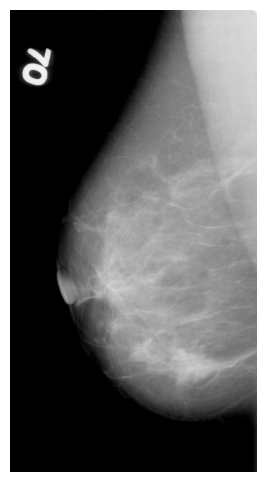

In [58]:
plt.figure(figsize=(6, 6))
plt.imshow(mlo_img, cmap="gray")
plt.axis('off')
plt.show()

## Create breast region of interest

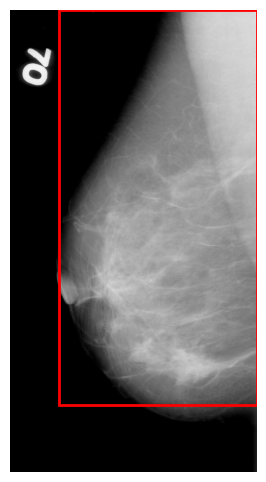

In [59]:
x, y, w, h = get_img_crop(mlo_img)

plt.figure(figsize=(6, 6))

plt.imshow(mlo_img, cmap="gray")
ax = plt.gca()

rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.axis('off')
plt.show()

## Crop image

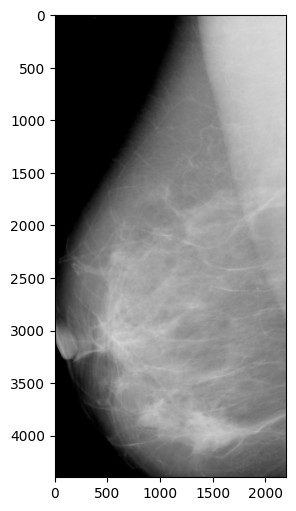

In [60]:
img_cropped = mlo_img[y:y+h, x:x+w]

plt.figure(figsize=(6, 6))
plt.imshow(img_cropped, cmap="gray")
plt.show()

## Resize to 512x512 (square image)

In [61]:
target_size = 512

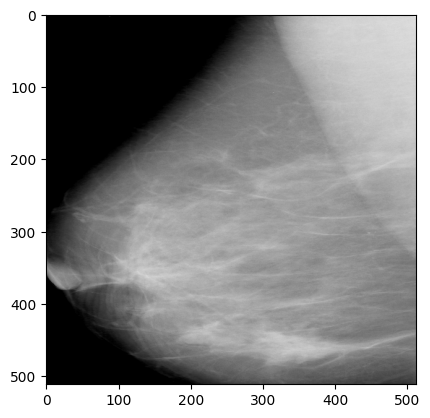

In [62]:
img_final = cv2.resize(img_cropped, (target_size, target_size))
plt.imshow(img_final, cmap="grey")
plt.show()

## Augmentation pipeline

The augmentation pipeline is applied at 512x512 resolution to preserve spatial detail,
then resized to 224x224 for model input.

In [63]:
# Convert to RGB (3 channels) as expected by the model
img_rgb = np.stack([img_final] * 3, axis=-1).astype(np.uint8)

# Get the training transform (augments at 512, outputs at 224)
train_transform = get_train_transform(aug_size=512, output_size=224)

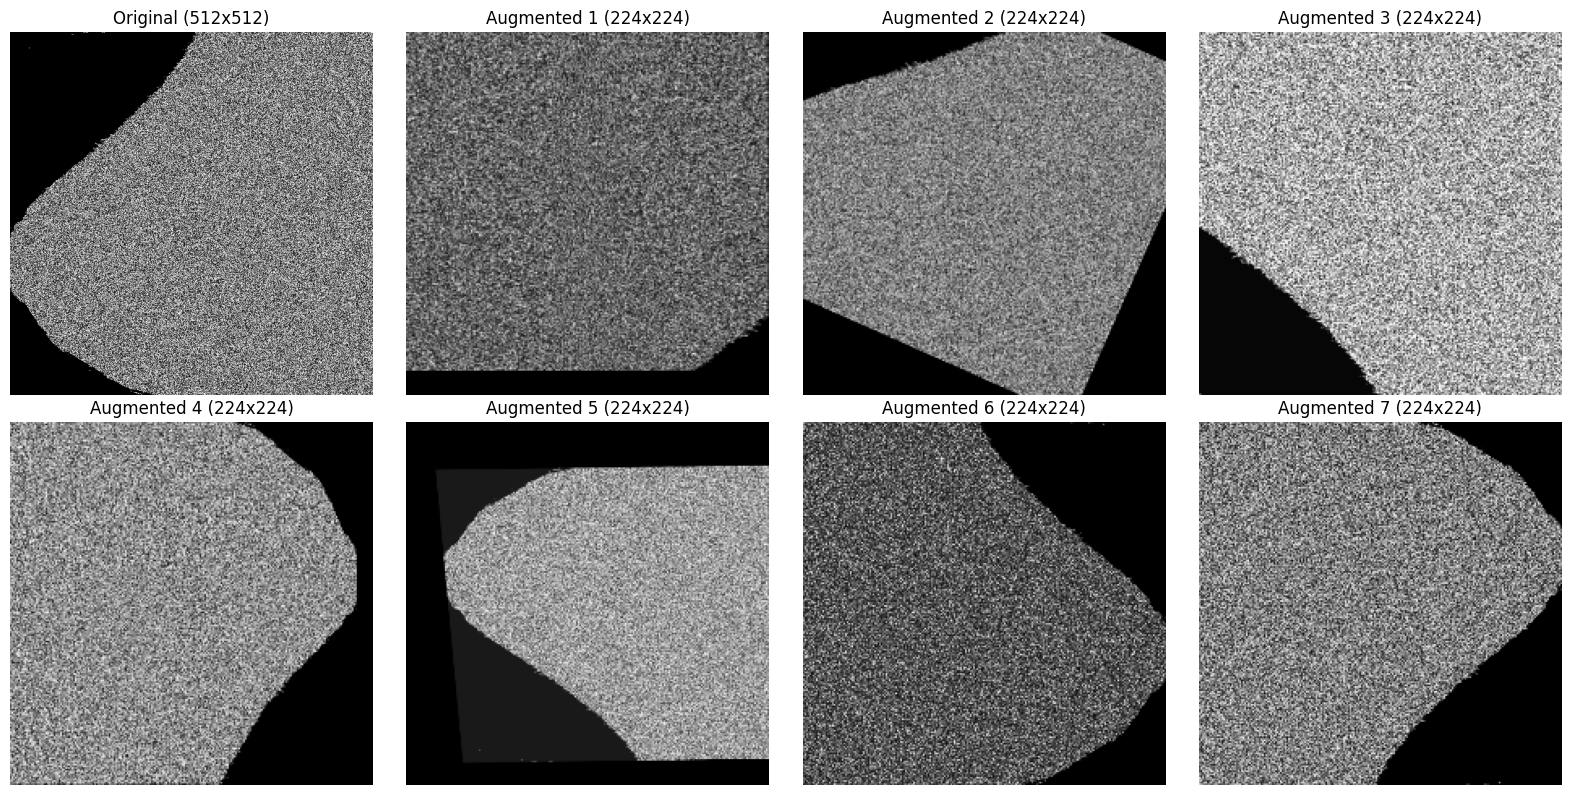

In [64]:
# Show multiple augmented versions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(img_rgb)
axes[0].set_title("Original (512x512)")
axes[0].axis('off')

for i in range(1, 8):
    augmented = train_transform(image=img_rgb)['image']
    axes[i].imshow(augmented)
    axes[i].set_title(f"Augmented {i} (224x224)")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Validation transform

For validation/inference, only resize is applied (no augmentation).

In [ ]:
val_transform = get_val_transform(output_size=224)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original (512x512)")
axes[0].axis('off')

val_img = val_transform(image=img_rgb)['image']
axes[1].imshow(val_img)
axes[1].set_title("Validation (224x224)")
axes[1].axis('off')

plt.tight_layout()
plt.show()